# Fase de Prueba — Evaluación de Resultados

**Proyecto de Aula — Inteligencia Artificial — III Corte (Fase 3)**  
Universidad Popular del Cesar — Facultad de Ingeniería de Sistemas — 2026-I  

**Integrantes:** Mateo López Patiño, Anaclaudia Vega Martínez.

**Docente:** Tonny Enrique Jiménez Márquez.

---

Este notebook carga los resultados del entrenamiento realizado en Kaggle y genera:

1. **Curvas de aprendizaje** — pérdida y AUC por época
2. **Tabla de métricas** — AUC-ROC, F1, Average Precision por patología
3. **Curvas ROC** — una por cada una de las 14 patologías
4. **Grad-CAM** — mapas de calor sobre radiografías reales
5. **Comparativa con CheXNet** — benchmark de Stanford

**Prerequisito:** Los archivos `best_model.pt`, `history.json`, `test_results.json` y `test_predictions.npz` deben estar en `outputs/models/`.

## 0. Imports y configuración

In [18]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import roc_curve, auc as sklearn_auc

warnings.filterwarnings('ignore')

# Rutas
MODELS_DIR  = Path('../outputs/models')
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(exist_ok=True)

PATHOLOGIES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass',
    'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema',
    'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia',
]

# AUC reportados en el paper CheXNet (Stanford, Rajpurkar et al. 2017)
CHEXNET_AUC = {
    'Atelectasis': 0.8094, 'Cardiomegaly': 0.9248, 'Effusion': 0.8638,
    'Infiltration': 0.7345, 'Mass': 0.8676, 'Nodule': 0.7802,
    'Pneumonia': 0.7680, 'Pneumothorax': 0.8887, 'Consolidation': 0.7901,
    'Edema': 0.8878, 'Emphysema': 0.9371, 'Fibrosis': 0.8047,
    'Pleural_Thickening': 0.7856, 'Hernia': 0.9164,
}

device = torch.device('cpu')
print('Setup listo. Device:', device)
print('Figuras se guardan en:', FIGURES_DIR.resolve())

Setup listo. Device: cpu
Figuras se guardan en: E:\Documentos\Universidad 2026-1\Inteligencia Artificial\Corte 3\proyecto_fase3\outputs\figures


## 1. Cargar todos los resultados del entrenamiento

In [19]:
# Cargar historial de entrenamiento
with open(MODELS_DIR / 'history.json') as f:
    history = json.load(f)

# Cargar métricas del test set
with open(MODELS_DIR / 'test_results.json') as f:
    test_results = json.load(f)

# Cargar predicciones del test set
data = np.load(MODELS_DIR / 'test_predictions.npz')
probs  = data['probs']   # (25596, 14) — probabilidades predichas
labels = data['labels']  # (25596, 14) — etiquetas reales

print(f'Épocas entrenadas:     {len(history)}')
print(f'Mejor época (val AUC): {test_results["best_epoch"]}')
print(f'Mejor val AUC:         {test_results["best_val_auc"]:.4f}')
print(f'Test AUC promedio:     {test_results["test_auc_mean"]:.4f}')
print(f'Imágenes en test set:  {probs.shape[0]:,}')

Épocas entrenadas:     10
Mejor época (val AUC): 7
Mejor val AUC:         0.8178
Test AUC promedio:     0.7938
Imágenes en test set:  25,596


## 2. Curvas de aprendizaje

Muestra cómo evolucionaron la pérdida y el AUC durante las 10 épocas de entrenamiento.

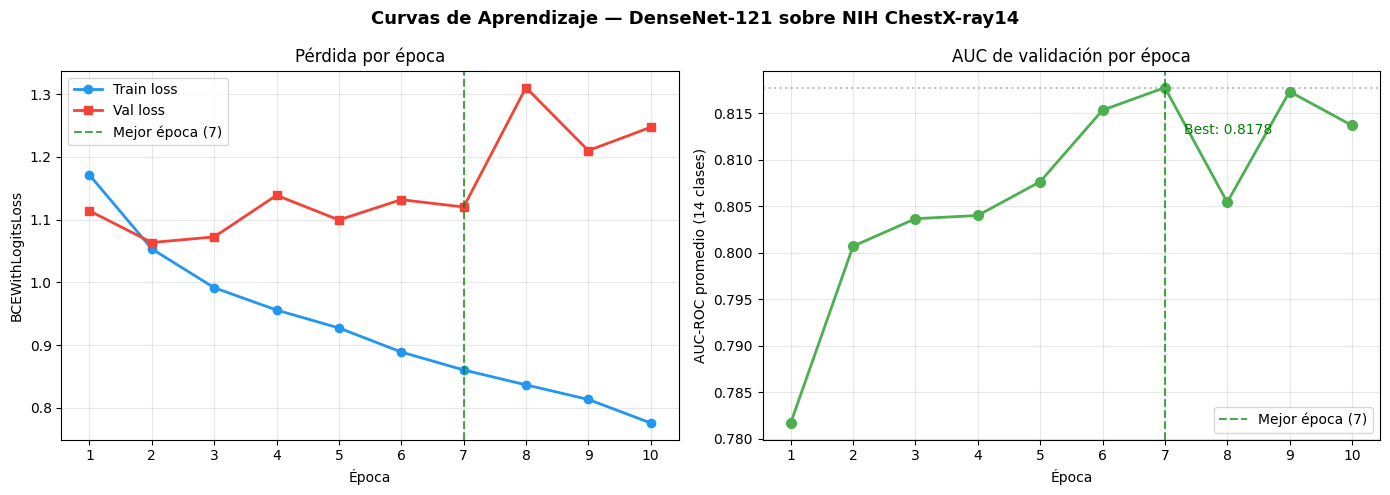

Guardado: outputs/figures/08_curvas_aprendizaje.png


In [20]:
epochs      = [h['epoch']       for h in history]
train_loss  = [h['train_loss']  for h in history]
val_loss    = [h['val_loss']    for h in history]
val_auc     = [h['val_auc_mean'] for h in history]
best_ep     = test_results['best_epoch']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizaje — DenseNet-121 sobre NIH ChestX-ray14',
             fontsize=13, fontweight='bold')

# — Pérdida —
ax = axes[0]
ax.plot(epochs, train_loss, 'o-', color='#2196F3', label='Train loss', linewidth=2)
ax.plot(epochs, val_loss,   's-', color='#F44336', label='Val loss',   linewidth=2)
ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Mejor época ({best_ep})')
ax.set_xlabel('Época'); ax.set_ylabel('BCEWithLogitsLoss')
ax.set_title('Pérdida por época')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(epochs)

# — AUC —
ax = axes[1]
ax.plot(epochs, val_auc, 'o-', color='#4CAF50', linewidth=2, markersize=7)
ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Mejor época ({best_ep})')
ax.axhline(test_results['best_val_auc'], color='gray', linestyle=':', alpha=0.5)
ax.annotate(f"Best: {test_results['best_val_auc']:.4f}",
            xy=(best_ep, test_results['best_val_auc']),
            xytext=(best_ep+0.3, test_results['best_val_auc']-0.005),
            fontsize=10, color='green')
ax.set_xlabel('Época'); ax.set_ylabel('AUC-ROC promedio (14 clases)')
ax.set_title('AUC de validación por época')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(epochs)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/figures/08_curvas_aprendizaje.png')

## 3. Tabla de métricas — AUC-ROC, F1 y Average Precision por patología

In [21]:
# Construir DataFrame con todas las métricas
rows = []
for p in PATHOLOGIES:
    rows.append({
        'Patología':         p,
        'AUC-ROC (nuestro)': round(test_results['test_auc_per_class'][p], 4),
        'AUC-ROC (CheXNet)': CHEXNET_AUC[p],
        'Diferencia':        round(test_results['test_auc_per_class'][p] - CHEXNET_AUC[p], 4),
        'F1-Score':          round(test_results['test_f1_per_class'][p], 4),
        'Avg Precision':     round(test_results['test_ap_per_class'][p], 4),
    })

df_metrics = pd.DataFrame(rows)

# Fila de promedios
avg_row = {
    'Patología': 'PROMEDIO',
    'AUC-ROC (nuestro)': round(df_metrics['AUC-ROC (nuestro)'].mean(), 4),
    'AUC-ROC (CheXNet)': round(df_metrics['AUC-ROC (CheXNet)'].mean(), 4),
    'Diferencia':        round(df_metrics['Diferencia'].mean(), 4),
    'F1-Score':          round(df_metrics['F1-Score'].mean(), 4),
    'Avg Precision':     round(df_metrics['Avg Precision'].mean(), 4),
}
df_metrics = pd.concat([df_metrics, pd.DataFrame([avg_row])], ignore_index=True)

# Mostrar con color
def color_diff(val):
    if val == 'PROMEDIO': return ''
    try:
        color = '#c8e6c9' if float(val) >= 0 else '#ffcdd2'
        return f'background-color: {color}'
    except:
        return ''

styled = df_metrics.style.map(color_diff, subset=['Diferencia'])\
                         .set_caption('Tabla 1 — Métricas por patología en el set de test NIH')\
                         .format({'AUC-ROC (nuestro)': '{:.4f}',
                                  'AUC-ROC (CheXNet)': '{:.4f}',
                                  'Diferencia': '{:+.4f}',
                                  'F1-Score': '{:.4f}',
                                  'Avg Precision': '{:.4f}'})
display(styled)

# Guardar CSV para el informe
df_metrics.to_csv(MODELS_DIR / 'metrics_table.csv', index=False)
print(f"\nTest AUC promedio:  {test_results['test_auc_mean']:.4f}")
print(f"CheXNet AUC promedio: {sum(CHEXNET_AUC.values())/len(CHEXNET_AUC):.4f}")

,Patología,AUC-ROC (nuestro),AUC-ROC (CheXNet),Diferencia,F1-Score,Avg Precision
0,Atelectasis,0.7439,0.8094,-0.0655,0.3258,0.3041
1,Cardiomegaly,0.8879,0.9248,-0.0369,0.2163,0.3215
2,Effusion,0.8138,0.8638,-0.0500,0.4610,0.4802
3,Infiltration,0.6883,0.7345,-0.0462,0.4576,0.3844
4,Mass,0.7948,0.8676,-0.0728,0.2607,0.2725
5,Nodule,0.7214,0.7802,-0.0588,0.1915,0.1958
6,Pneumonia,0.6770,0.7680,-0.0910,0.0648,0.0431
7,Pneumothorax,0.8377,0.8887,-0.0510,0.3652,0.3628
8,Consolidation,0.7379,0.7901,-0.0522,0.1986,0.1601
9,Edema,0.8362,0.8878,-0.0516,0.1661,0.1571



Test AUC promedio:  0.7938
CheXNet AUC promedio: 0.8399


## 4. Gráfica de AUC por clase — comparativa con CheXNet

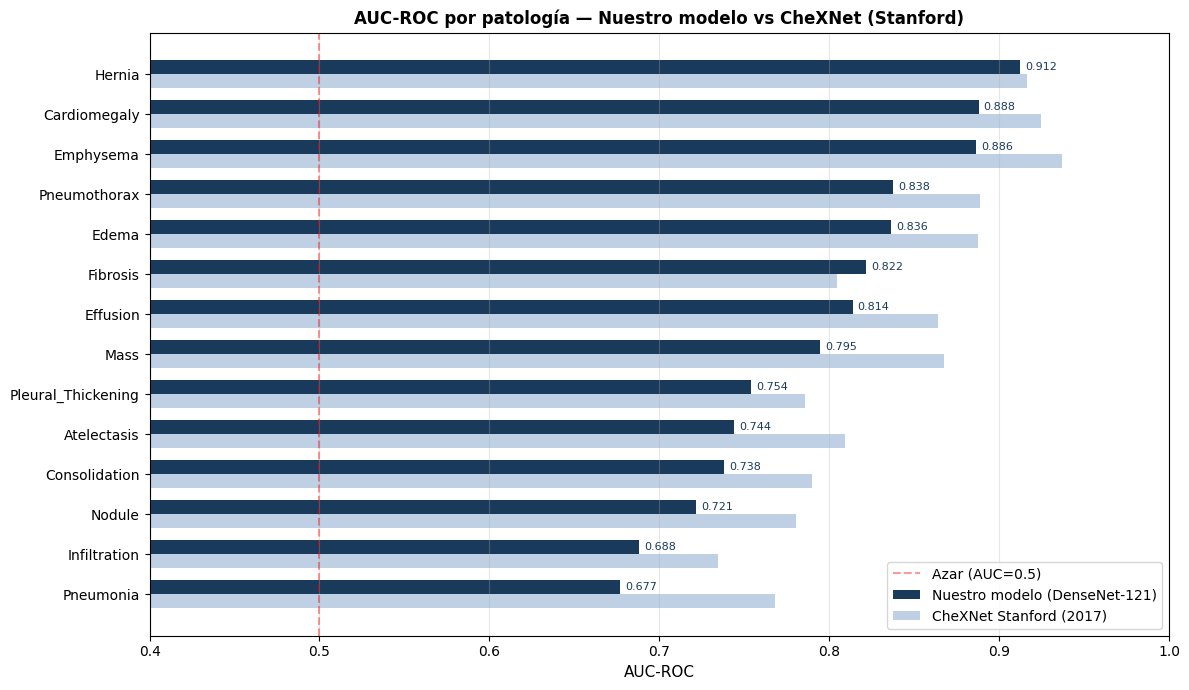

Guardado: outputs/figures/09_auc_por_clase.png


In [22]:
df_plot = df_metrics[df_metrics['Patología'] != 'PROMEDIO'].copy()
df_plot = df_plot.sort_values('AUC-ROC (nuestro)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

y = np.arange(len(df_plot))
h = 0.35

bars1 = ax.barh(y + h/2, df_plot['AUC-ROC (nuestro)'], h,
                color='#1a3a5c', label='Nuestro modelo (DenseNet-121)')
bars2 = ax.barh(y - h/2, df_plot['AUC-ROC (CheXNet)'], h,
                color='#b0c4de', label='CheXNet Stanford (2017)', alpha=0.8)

ax.set_yticks(y)
ax.set_yticklabels(df_plot['Patología'], fontsize=10)
ax.set_xlabel('AUC-ROC', fontsize=11)
ax.set_title('AUC-ROC por patología — Nuestro modelo vs CheXNet (Stanford)',
             fontsize=12, fontweight='bold')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='Azar (AUC=0.5)')
ax.set_xlim(0.4, 1.0)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Etiquetas de valor
for bar in bars1:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8, color='#1a3a5c')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_auc_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/figures/09_auc_por_clase.png')

## 5. Curvas ROC — una por cada patología

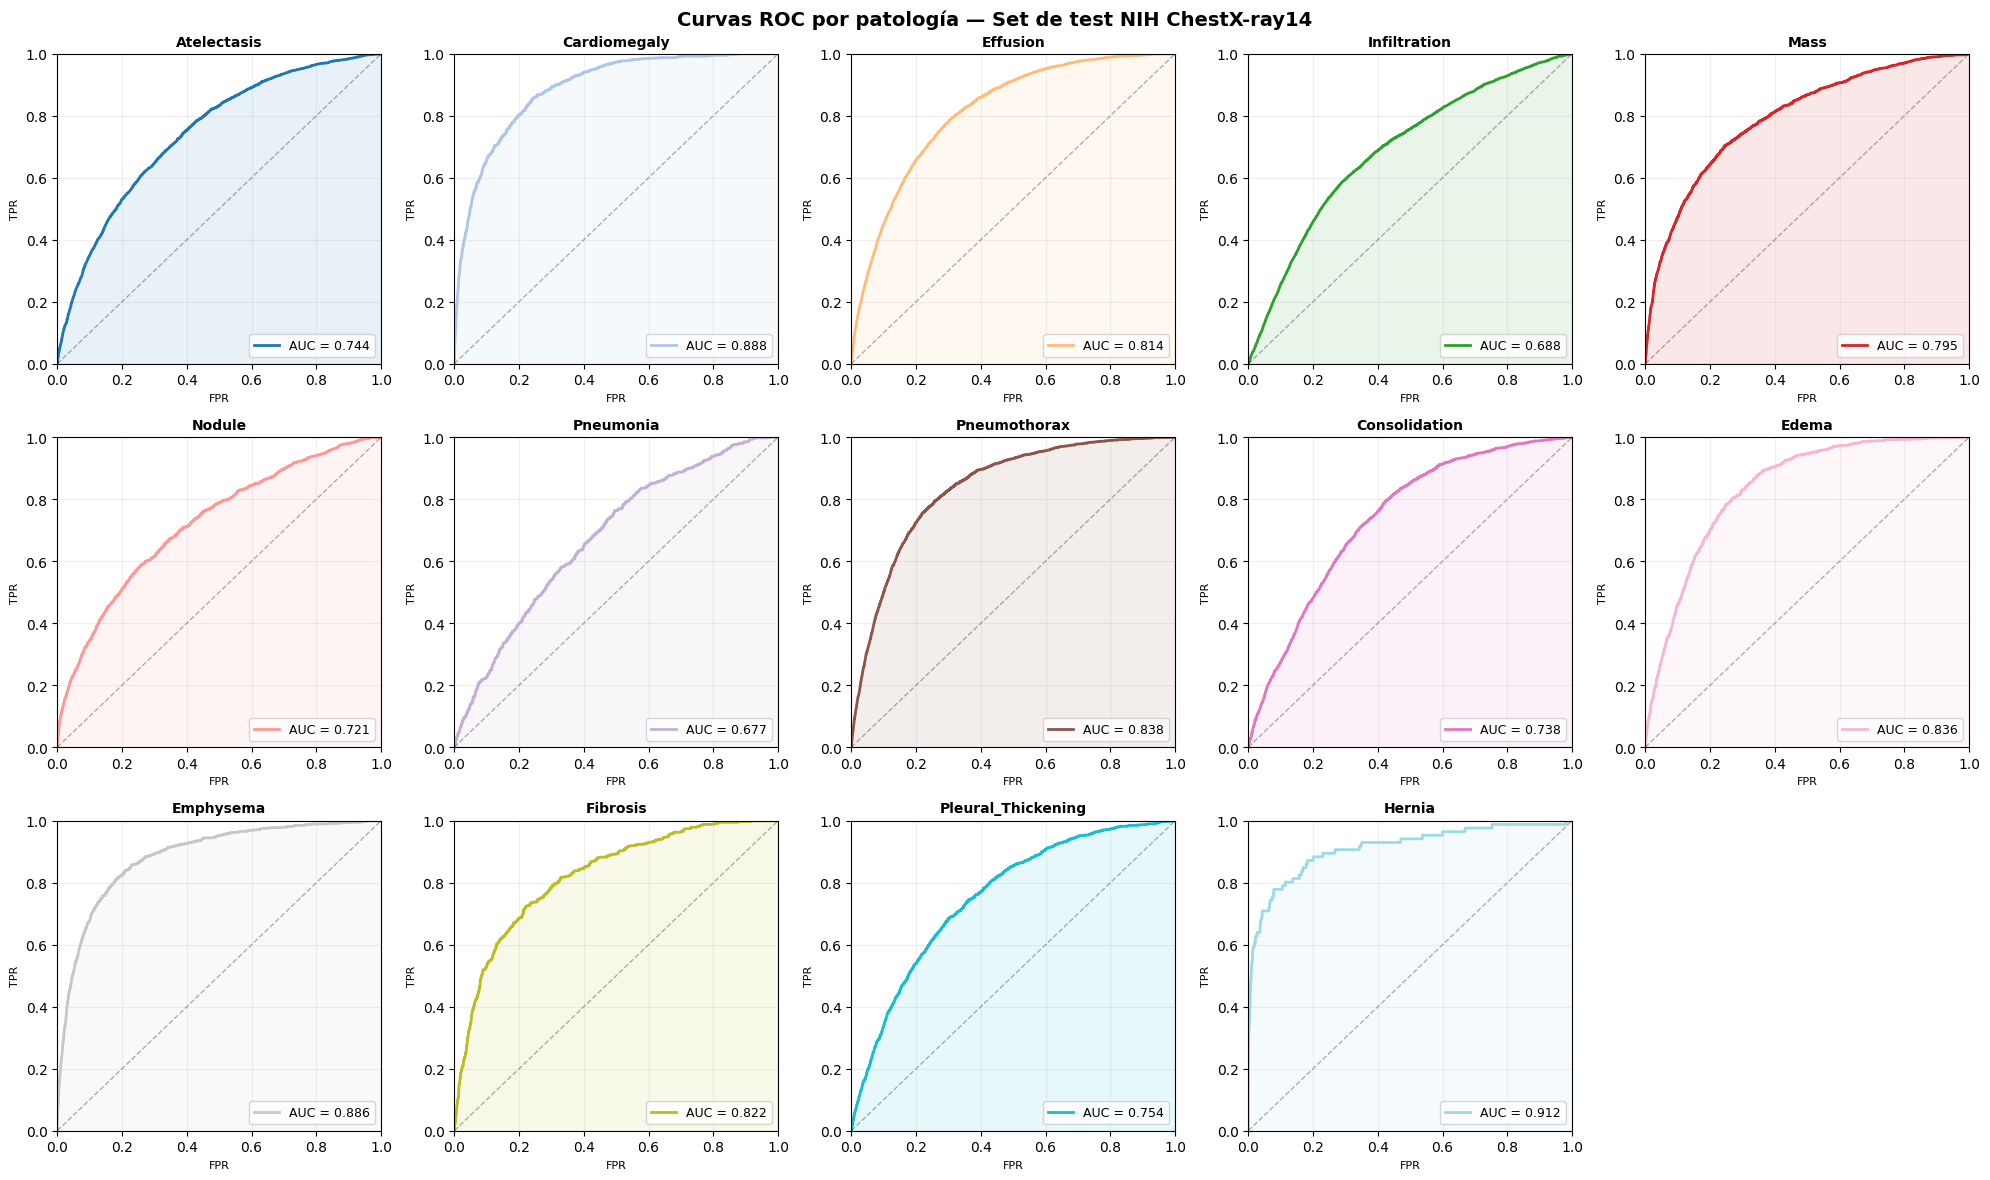

Guardado: outputs/figures/10_curvas_roc.png


In [23]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Curvas ROC por patología — Set de test NIH ChestX-ray14',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

colors = plt.cm.tab20(np.linspace(0, 1, 14))

for i, (patho, color) in enumerate(zip(PATHOLOGIES, colors)):
    ax = axes_flat[i]
    fpr, tpr, _ = roc_curve(labels[:, i], probs[:, i])
    roc_auc = sklearn_auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'AUC = {roc_auc:.3f}')
    ax.plot([0,1], [0,1], 'k--', alpha=0.3, linewidth=1)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)

    ax.set_title(patho, fontsize=10, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.2)
    ax.set_xlim([0,1]); ax.set_ylim([0,1])

# Ocultar el subplot extra (tenemos 14 patologías en 15 subplots)
axes_flat[14].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/figures/10_curvas_roc.png')

## 6. Análisis de errores — distribución de predicciones

¿Cómo distribuye el modelo las probabilidades en casos positivos vs negativos?

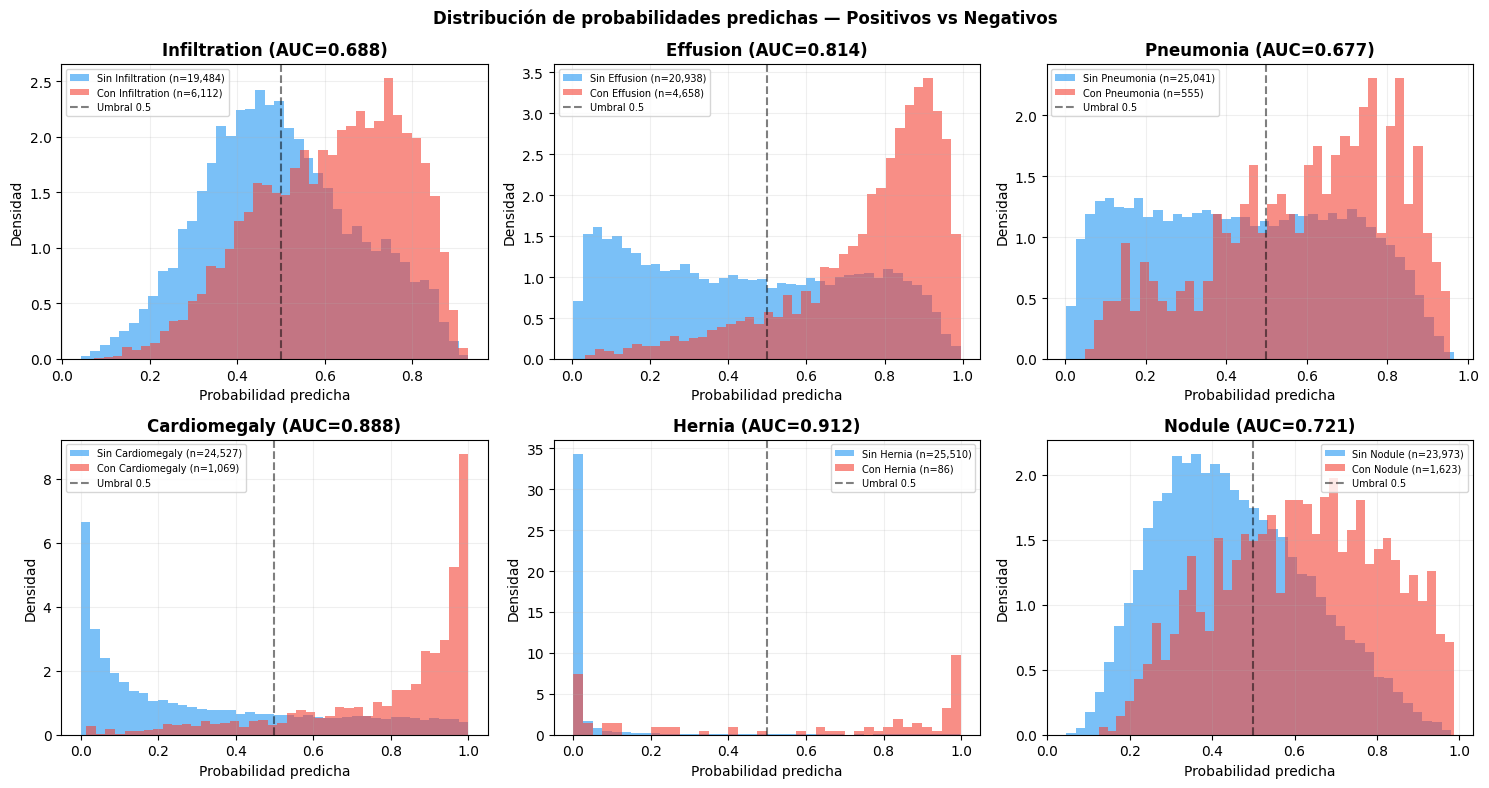

Guardado: outputs/figures/11_distribucion_predicciones.png


In [24]:
# Mostrar distribución de probabilidades para 6 patologías clave
pathos_show = ['Infiltration', 'Effusion', 'Pneumonia',
               'Cardiomegaly', 'Hernia', 'Nodule']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de probabilidades predichas — Positivos vs Negativos',
             fontsize=12, fontweight='bold')

for ax, patho in zip(axes.flatten(), pathos_show):
    i = PATHOLOGIES.index(patho)
    pos_probs = probs[labels[:, i] == 1, i]
    neg_probs = probs[labels[:, i] == 0, i]

    ax.hist(neg_probs, bins=40, alpha=0.6, color='#2196F3',
            label=f'Sin {patho} (n={len(neg_probs):,})', density=True)
    ax.hist(pos_probs, bins=40, alpha=0.6, color='#F44336',
            label=f'Con {patho} (n={len(pos_probs):,})', density=True)
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Umbral 0.5')

    auc_val = test_results['test_auc_per_class'][patho]
    ax.set_title(f'{patho} (AUC={auc_val:.3f})', fontweight='bold')
    ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=7); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '11_distribucion_predicciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: outputs/figures/11_distribucion_predicciones.png')

## 7. Grad-CAM — Mapas de calor sobre radiografías

**¿Qué es Grad-CAM?**  
Muestra en qué zona de la radiografía se fijó el modelo para hacer cada predicción.  
Rojo = zona más relevante para la predicción.

**Prerequisito:** Necesitas algunas imágenes de muestra en `data/sample_images/`.  
Descarga 4-5 imágenes PNG del dataset NIH desde Kaggle y ponlas ahí.  
Puedes obtener los nombres de imagen del CSV: `data/processed/metadata_with_splits.csv`

In [25]:
# Verificar que tenemos imágenes de muestra
SAMPLE_DIR = Path('../data/sample_images')
SAMPLE_DIR.mkdir(exist_ok=True)

sample_images = list(SAMPLE_DIR.glob('*.png'))
print(f'Imágenes de muestra encontradas: {len(sample_images)}')

if len(sample_images) == 0:
    print()
    print('⚠️  No hay imágenes en data/sample_images/')
    print()
    print('Para descargar imágenes de muestra:')
    print('1. Ve a Kaggle → tu notebook → Output')
    print('2. O ve a: kaggle.com/datasets/nih-chest-xrays/data')
    print('3. Descarga 4-5 archivos PNG de cualquier subcarpeta images_00X/')
    print('4. Ponlos en: proyecto_fase3/data/sample_images/')
    print()
    print('IDs de ejemplo del test set (busca estos archivos):')
    df_splits = pd.read_csv('../data/processed/metadata_with_splits.csv')
    test_ids = df_splits[df_splits['split'] == 'test']['image_id'].head(5).tolist()
    for img_id in test_ids:
        print(f'  {img_id}')
else:
    for p in sample_images:
        print(f'  {p.name}')

Imágenes de muestra encontradas: 5
  00013774_034.png
  00013774_042.png
  00013774_054.png
  00013774_059.png
  00013777_000.png


In [26]:
# Cargar el modelo para Grad-CAM
class DenseNetCheXNet(nn.Module):
    def __init__(self, n_classes=14):
        super().__init__()
        backbone = models.densenet121(weights=None)
        backbone.classifier = nn.Linear(backbone.classifier.in_features, n_classes)
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x)

model = DenseNetCheXNet()
ckpt = torch.load(MODELS_DIR / 'best_model.pt', map_location='cpu')
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Modelo cargado — época {ckpt["epoch"]} — val_AUC={ckpt["val_auc"]:.4f}')

# Transforms para inferencia
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

Modelo cargado — época 7 — val_AUC=0.8178


In [27]:
def generate_gradcam(model, img_tensor, target_class_idx):
    """Genera mapa de calor Grad-CAM para la clase indicada."""
    # Capa objetivo: última capa convolucional de DenseNet-121
    target_layer = model.backbone.features.denseblock4

    gradients = []
    activations = []

    def save_gradient(grad):
        gradients.append(grad)

    def forward_hook(module, input, output):
        activations.append(output)
        output.register_hook(save_gradient)

    hook = target_layer.register_forward_hook(forward_hook)

    img_tensor = img_tensor.unsqueeze(0).requires_grad_(True)
    logits = model(img_tensor)
    score = logits[0, target_class_idx]
    model.zero_grad()
    score.backward()

    hook.remove()

    grads   = gradients[0].squeeze().detach().numpy()   # (C, H, W)
    acts    = activations[0].squeeze().detach().numpy()  # (C, H, W)
    weights = grads.mean(axis=(1, 2))                    # (C,)
    cam     = np.maximum((weights[:, None, None] * acts).sum(axis=0), 0)

    # Normalizar a [0, 1]
    cam -= cam.min()
    if cam.max() > 0:
        cam /= cam.max()

    return cam


def denormalize(tensor):
    """Convierte tensor normalizado a imagen RGB visualizable."""
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    img  = tensor.permute(1, 2, 0).numpy()
    img  = img * std + mean
    return np.clip(img, 0, 1)


print('Funciones Grad-CAM listas.')

Funciones Grad-CAM listas.


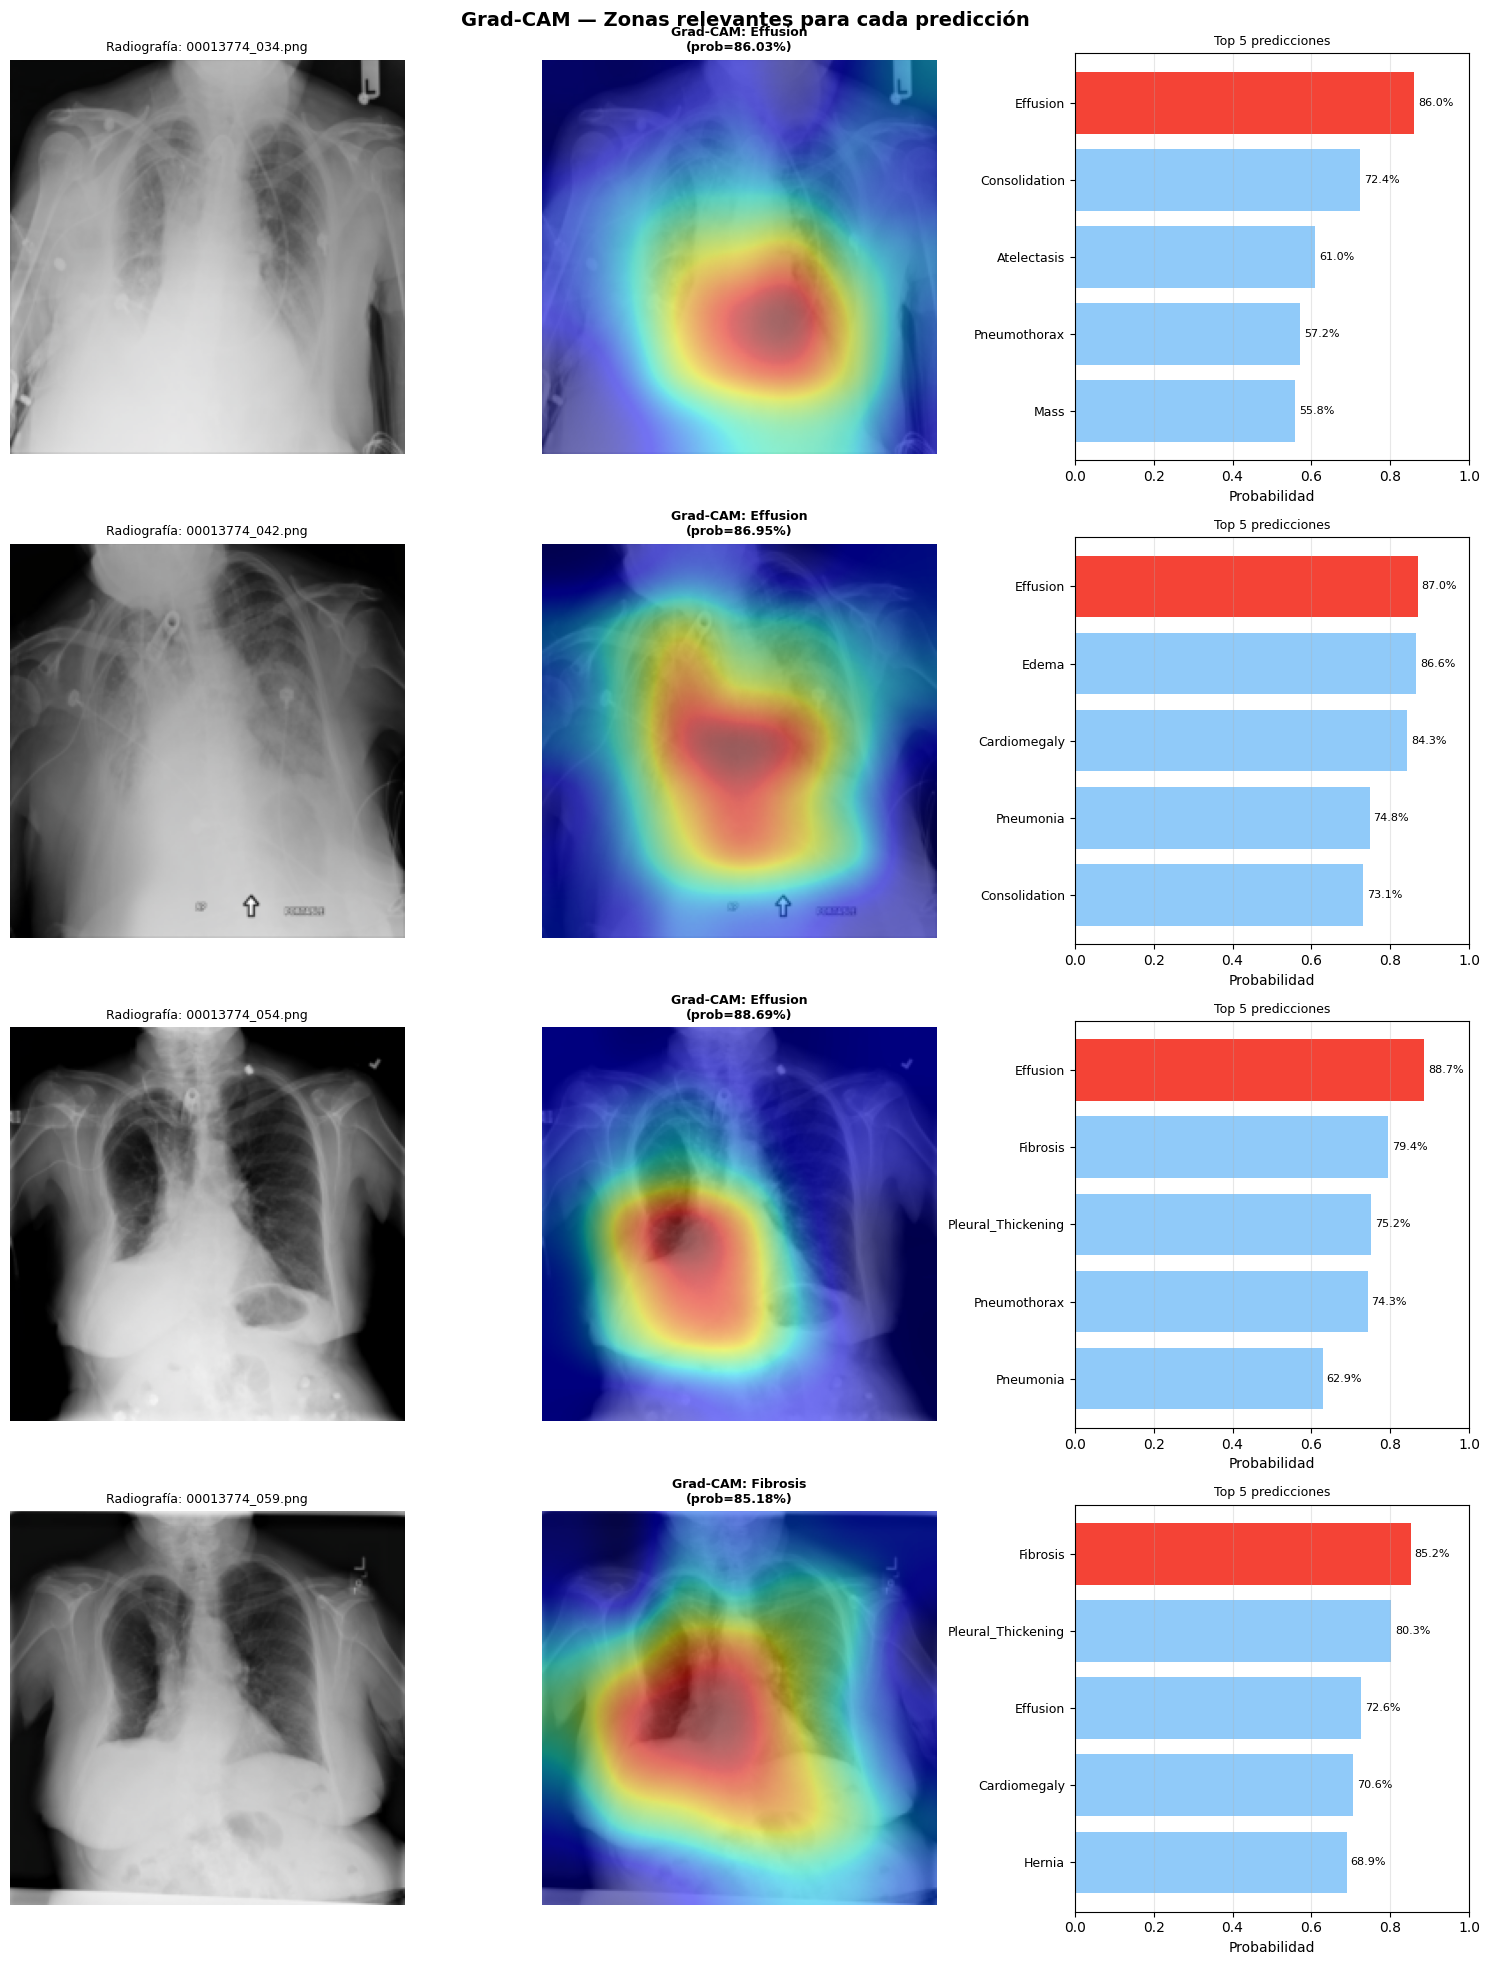

Guardado: outputs/figures/12_gradcam.png


In [28]:
sample_images = list(SAMPLE_DIR.glob('*.png'))

if len(sample_images) == 0:
    print('Agrega imágenes PNG a data/sample_images/ y vuelve a correr esta celda.')
else:
    n_imgs = min(len(sample_images), 4)
    # Mostrar las predicciones más altas para elegir qué patología visualizar
    fig, axes = plt.subplots(n_imgs, 3, figsize=(15, 5 * n_imgs))
    if n_imgs == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle('Grad-CAM — Zonas relevantes para cada predicción',
                 fontsize=14, fontweight='bold')

    for row_idx, img_path in enumerate(sample_images[:n_imgs]):
        img_pil    = Image.open(img_path)
        img_tensor = transform(img_pil)
        img_rgb    = denormalize(img_tensor)

        # Predicción del modelo
        with torch.no_grad():
            logits = model(img_tensor.unsqueeze(0))
            probs_img = torch.sigmoid(logits).squeeze().numpy()

        top_class_idx  = int(probs_img.argmax())
        top_class_name = PATHOLOGIES[top_class_idx]
        top_prob       = probs_img[top_class_idx]

        # Generar Grad-CAM para la clase con mayor probabilidad
        cam = generate_gradcam(model, img_tensor, top_class_idx)
        cam_resized = np.array(Image.fromarray(cam).resize((224, 224)))
        heatmap = plt.cm.jet(cam_resized)[:, :, :3]
        overlay = 0.5 * img_rgb + 0.5 * heatmap
        overlay = np.clip(overlay, 0, 1)

        # Columna 1: imagen original
        axes[row_idx, 0].imshow(img_rgb, cmap='gray')
        axes[row_idx, 0].set_title(f'Radiografía: {img_path.name}', fontsize=9)
        axes[row_idx, 0].axis('off')

        # Columna 2: mapa de calor
        axes[row_idx, 1].imshow(img_rgb, cmap='gray')
        axes[row_idx, 1].imshow(cam_resized, cmap='jet', alpha=0.5)
        axes[row_idx, 1].set_title(f'Grad-CAM: {top_class_name}\n(prob={top_prob:.2%})',
                                    fontsize=9, fontweight='bold')
        axes[row_idx, 1].axis('off')

        # Columna 3: top 5 predicciones
        top5_idx   = probs_img.argsort()[::-1][:5]
        top5_names = [PATHOLOGIES[i] for i in top5_idx]
        top5_probs = probs_img[top5_idx]
        colors_bar = ['#F44336' if i == top_class_idx else '#90CAF9' for i in top5_idx]
        axes[row_idx, 2].barh(range(5), top5_probs[::-1], color=colors_bar[::-1])
        axes[row_idx, 2].set_yticks(range(5))
        axes[row_idx, 2].set_yticklabels(top5_names[::-1], fontsize=9)
        axes[row_idx, 2].set_xlabel('Probabilidad')
        axes[row_idx, 2].set_title('Top 5 predicciones', fontsize=9)
        axes[row_idx, 2].set_xlim(0, 1)
        axes[row_idx, 2].grid(axis='x', alpha=0.3)
        for j, (v, c) in enumerate(zip(top5_probs[::-1], colors_bar[::-1])):
            axes[row_idx, 2].text(v + 0.01, j, f'{v:.1%}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '12_gradcam.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: outputs/figures/12_gradcam.png')

## 8. Resumen final — todas las métricas

In [29]:
print('=' * 60)
print('RESUMEN DE RESULTADOS — FASE DE PRUEBA')
print('=' * 60)
print(f"Modelo:          DenseNet-121 con Transfer Learning")
print(f"Dataset:         NIH ChestX-ray14")
print(f"Test set:        25,596 imágenes")
print(f"Mejor época:     {ckpt['epoch']} / 10")
print(f"Val AUC:         {ckpt['val_auc']:.4f}")
print(f"Test AUC medio:  {test_results['test_auc_mean']:.4f}")
print(f"CheXNet AUC med: {sum(CHEXNET_AUC.values())/len(CHEXNET_AUC):.4f}")
print()
print('AUC por patología:')
print(f"  {'Patología':<22} {'Nuestro':>8} {'CheXNet':>8} {'Dif':>7}")
print('  ' + '-'*50)
for p in PATHOLOGIES:
    our = test_results['test_auc_per_class'][p]
    ref = CHEXNET_AUC[p]
    diff = our - ref
    arrow = '↑' if diff >= 0 else '↓'
    print(f"  {p:<22} {our:>8.4f} {ref:>8.4f} {diff:>+7.4f} {arrow}")
print('=' * 60)
print()
print('Figuras generadas:')
for f in sorted(FIGURES_DIR.glob('0[89]_*.png')) + sorted(FIGURES_DIR.glob('1[012]_*.png')):
    print(f'  {f.name}')

RESUMEN DE RESULTADOS — FASE DE PRUEBA
Modelo:          DenseNet-121 con Transfer Learning
Dataset:         NIH ChestX-ray14
Test set:        25,596 imágenes
Mejor época:     7 / 10
Val AUC:         0.8178
Test AUC medio:  0.7938
CheXNet AUC med: 0.8399

AUC por patología:
  Patología               Nuestro  CheXNet     Dif
  --------------------------------------------------
  Atelectasis              0.7439   0.8094 -0.0655 ↓
  Cardiomegaly             0.8879   0.9248 -0.0369 ↓
  Effusion                 0.8138   0.8638 -0.0500 ↓
  Infiltration             0.6883   0.7345 -0.0462 ↓
  Mass                     0.7948   0.8676 -0.0728 ↓
  Nodule                   0.7214   0.7802 -0.0588 ↓
  Pneumonia                0.6770   0.7680 -0.0910 ↓
  Pneumothorax             0.8377   0.8887 -0.0510 ↓
  Consolidation            0.7379   0.7901 -0.0522 ↓
  Edema                    0.8362   0.8878 -0.0516 ↓
  Emphysema                0.8864   0.9371 -0.0507 ↓
  Fibrosis                 0.8218   0.8